# 06_04 · Evaluación Final — Sistema completo (3 capas)

Evaluación de los **modelos de producción** construidos en `06_01`–`06_03`.
Cada capa se evalúa de forma distinta porque no tienen el mismo tipo de *ground truth*:

| Capa | Qué se puede evaluar | Qué no |
|---|---|---|
| 1 — SPARK | Consistencia de tasa de anomalías entre máquinas, estabilidad | Recall/precision reales — no hay etiquetas de fallo |
| 2 — Mecánica | F1/AUC LOO de `kit_model` y `cnc_model` contra baseline trivial | Generalización (n=33 / n=18) |
| 3 — AI4I | Métricas completas en test, impacto de negocio, FN, SHAP | — |
| Sistema | Proyección económica **solo de la Capa 3** (única con test real) + roles cualitativos de capas 1-2 | Evaluación end-to-end: no existe dataset con las señales de las 3 capas juntas |


In [5]:
import sys; sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from paths import PROCESSED, MODELS

with open(os.path.join(PROCESSED, 'splits.pkl'), 'rb') as f:
    splits = pickle.load(f)
with open(os.path.join(MODELS, 'models.pkl'), 'rb') as f:
    models = pickle.load(f)
X_train, X_test, y_train, y_test = splits['ai4i']

with open(os.path.join(MODELS, 'kit_model.pkl'), 'rb') as f:
    kit_bundle = pickle.load(f)
with open(os.path.join(MODELS, 'cnc_model.pkl'), 'rb') as f:
    cnc_bundle = pickle.load(f)
with open(os.path.join(MODELS, 'model_config.yaml')) as f:
    cfg = yaml.safe_load(f)

print('Artefactos cargados:')
print(f"  Capa 2 KIT: {kit_bundle['metrics_loo']}")
print(f"  Capa 2 CNC: {cnc_bundle['metrics_loo']} (trivial: {cnc_bundle['f1_trivial']})")
print(f"  Capa 3 AI4I: {cfg['performance']}")


Artefactos cargados:
  Capa 2 KIT: {'f1': 0.667, 'recall': 0.667, 'precision': 0.667, 'auc': 0.707}
  Capa 2 CNC: {'f1': 0.909, 'recall': 1.0, 'precision': 0.833, 'auc': 0.85} (trivial: 0.714)
  Capa 3 AI4I: {'precision': 0.9667, 'recall': 0.8529, 'f1': 0.9062, 'roc_auc': 0.9783, 'fn': 10, 'fp': 2}


## 1. Capa 1 — SPARK (no supervisado)

Sin etiquetas de fallo, lo evaluable es la **consistencia del detector**: si la tasa de
anomalías fuera muy dispar entre máquinas, el modelo estaría capturando diferencias de
régimen de trabajo y no anomalías. La tasa media debe rondar el `contamination` usado.


In [6]:
spark_summary = pd.read_csv(os.path.join(PROCESSED, 'spark_tec_anomaly_summary.csv'), index_col=0)
print(spark_summary[['minutos_validos', 'minutos_anomalia', 'pct_anomalia', 'pct_gap']].round(2).to_string())

print(f"\nTasa media de anomalías: {spark_summary['pct_anomalia'].mean():.2f}%")
print(f"Desviación entre máquinas: {spark_summary['pct_anomalia'].std():.2f} pp")

prod_path = os.path.join(MODELS, 'spark_models.pkl')
if os.path.exists(prod_path):
    with open(prod_path, 'rb') as f:
        sp = pickle.load(f)
    print(f"\nBundle de producción (06_01): params={sp['params']}")
else:
    print('\n⚠ models/spark_models.pkl no existe aún — los scored vienen de 03_04 (defaults).')
    print('  Ejecuta 06_01 para promocionar los hiperparámetros afinados.')


           minutos_validos  minutos_anomalia  pct_anomalia  pct_gap
machine                                                            
48S                  15802               791          5.01    97.00
CFST161             477781             23889          5.00     9.35
CTX800TC             65787              3290          5.00    87.52
Chiron800           104596              5230          5.00    80.15
DMF3008              89196              4460          5.00    83.08
DMU125MB             73744              3688          5.00    86.01
DNG50evo            477786             23890          5.00     9.35
E110                 83161              4158          5.00    84.22
E30D2                85165              4259          5.00    83.84
JWA24               477788             23890          5.00     9.35
MV2400R             181588              9080          5.00    65.55

Tasa media de anomalías: 5.00%
Desviación entre máquinas: 0.00 pp

Bundle de producción (06_01): params={'n_estimat

## 2. Capa 2 — Mecánica (KIT prototipo + CNC cold-start)

Métricas LOO leídas de los bundles construidos en `06_02`. La referencia honesta es el
**baseline trivial** de cada dataset (predecir siempre la clase mayoritaria positiva).


                           f1  recall  precision    auc  F1 trivial
KIT (prototipo, n=33)   0.667   0.667      0.667  0.707       0.625
CNC (cold-start, n=18)  0.909   1.000      0.833  0.850       0.714


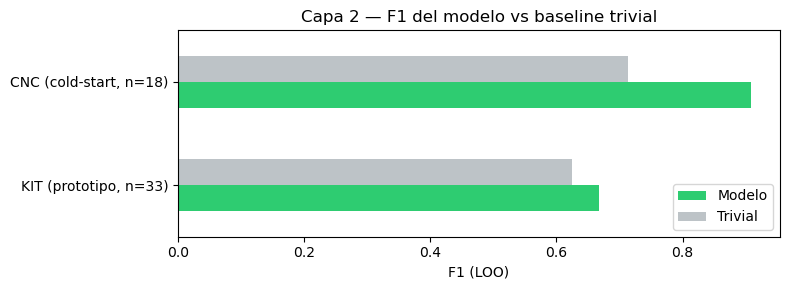


→ El CNC supera claramente su trivial (0.909 vs 0.714); el KIT lo supera con
  menos margen — su papel es de prototipo conceptual, no de producción.


In [7]:
from sklearn.metrics import f1_score

kit_df = pd.read_csv(os.path.join(PROCESSED, 'industrial_features_v2.csv'))
y_kit_triv = f1_score(kit_df['anomaly'], np.ones(len(kit_df)))

m_kit, m_cnc = kit_bundle['metrics_loo'], cnc_bundle['metrics_loo']
tabla = pd.DataFrame({
    'KIT (prototipo, n=33)': {**m_kit, 'F1 trivial': round(float(y_kit_triv), 3)},
    'CNC (cold-start, n=18)': {**m_cnc, 'F1 trivial': cnc_bundle['f1_trivial']},
}).T
print(tabla.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
tabla[['f1', 'F1 trivial']].plot(kind='barh', ax=ax, color=['#2ecc71', '#bdc3c7'])
ax.set_xlabel('F1 (LOO)')
ax.set_title('Capa 2 — F1 del modelo vs baseline trivial')
ax.legend(['Modelo', 'Trivial'])
plt.tight_layout(); plt.show()

print('\n→ El CNC supera claramente su trivial (0.909 vs 0.714); el KIT lo supera con')
print('  menos margen — su papel es de prototipo conceptual, no de producción.')


## 3. Capa 3 — AI4I (modelo de producción)

El modelo estrella: StackingClassifier con umbral optimizado. Secciones heredadas de la
evaluación original, ahora dentro de la evaluación global del sistema.


### 3.1 Impacto de negocio — Cuantificación económica

En mantenimiento predictivo industrial los dos tipos de error tienen costes muy distintos:

| Error | Consecuencia | Coste estimado |
|---|---|---|
| **Falso Negativo** | Fallo no detectado → parada imprevista + reparación de emergencia | ~3 000 €/fallo |
| **Falso Positivo** | Alarma falsa → revisión preventiva innecesaria | ~300 €/alarma |

*Costes calibrados para una pyme con equipos de criticidad media (un fallo no detectado cuesta ~10× una alarma falsa).*


                                     FN/año  FP/año Coste FN (€) Coste FP (€) Coste total (€)
Escenario                                                                                    
Sin modelo (ninguna detección)          816       0    2,448,000            0       2,448,000
Stacking — umbral 0.9766 (prod)         132      60      396,000       18,000         414,000
Stacking — umbral 0.75 (más recall)     108     300      324,000       90,000         414,000

=== ROI del modelo (umbral 0.9766) ===
Coste sin modelo:  €   2,448,000/año
Coste con modelo:  €     414,000/año
Ahorro estimado:   €   2,034,000/año  (83% reducción)


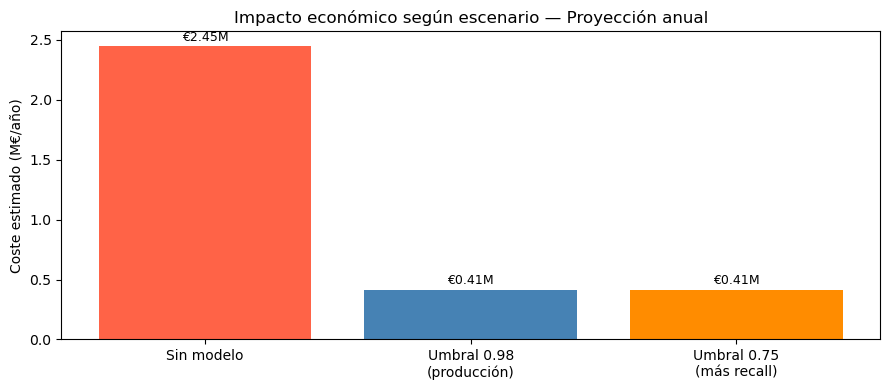

In [8]:
# ── Proyección anual (escalar de 2000 muestras de test a 1 año de producción) ─
scale_factor = 12   # asumimos ~1 mes de operación por cada 2000 muestras

cost_fn = 3_000    # € por fallo no detectado (pyme, criticidad media)
cost_fp = 300      # € por alarma falsa

# FN/FP derivados del modelo de producción cargado — antes estaban
# hardcodeados y quedaban obsoletos al re-entrenar
try:
    stack     = models['stacking_best']
    thr_prod  = models['stacking_best_threshold']
except KeyError:
    raise KeyError('Ejecuta antes los notebooks 05_01 para generar stacking_best en models.pkl')

y_prob_stack = stack.predict_proba(X_test)[:, 1]

def fn_fp(thr):
    y_pred = (y_prob_stack >= thr).astype(int)
    return (int(((y_pred == 0) & (y_test == 1)).sum()),
            int(((y_pred == 1) & (y_test == 0)).sum()))

fn_prod, fp_prod = fn_fp(thr_prod)
fn_rec,  fp_rec  = fn_fp(0.75)

scenarios = {
    'Sin modelo (ninguna detección)':           {'fn': int(y_test.sum()), 'fp': 0},
    f'Stacking — umbral {thr_prod:.4f} (prod)': {'fn': fn_prod, 'fp': fp_prod},
    'Stacking — umbral 0.75 (más recall)':      {'fn': fn_rec,  'fp': fp_rec},
}

rows = []
for name, vals in scenarios.items():
    fn_yr = vals['fn'] * scale_factor
    fp_yr = vals['fp'] * scale_factor
    coste = fn_yr * cost_fn + fp_yr * cost_fp
    rows.append({'Escenario': name,
                 'FN/año': fn_yr, 'FP/año': fp_yr,
                 'Coste FN (€)':    f"{fn_yr * cost_fn:,.0f}",
                 'Coste FP (€)':    f"{fp_yr * cost_fp:,.0f}",
                 'Coste total (€)': f"{coste:,.0f}"})

df_biz = pd.DataFrame(rows).set_index('Escenario')
print(df_biz.to_string())

costes = [v['fn'] * scale_factor * cost_fn + v['fp'] * scale_factor * cost_fp
          for v in scenarios.values()]
sin_modelo, con_modelo, con_recall = costes
ahorro = sin_modelo - con_modelo

print(f'\n=== ROI del modelo (umbral {thr_prod:.4f}) ===')
print(f'Coste sin modelo:  €{sin_modelo:>12,.0f}/año')
print(f'Coste con modelo:  €{con_modelo:>12,.0f}/año')
print(f'Ahorro estimado:   €{ahorro:>12,.0f}/año  ({ahorro/sin_modelo:.0%} reducción)')

# Gráfico de barras de costes
fig, ax = plt.subplots(figsize=(9, 4))
labels = ['Sin modelo', f'Umbral {thr_prod:.2f}\n(producción)', 'Umbral 0.75\n(más recall)']
bars = ax.bar(labels, [c/1e6 for c in costes],
              color=['tomato', 'steelblue', 'darkorange'])
ax.set_ylabel('Coste estimado (M€/año)')
ax.set_title('Impacto económico según escenario — Proyección anual')
for bar, c in zip(bars, costes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'€{c/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


---
### 3.2 Análisis de Falsos Negativos

Con el umbral óptimo (0.9845), el modelo se escapa **10 fallos** de 68 en test.
Análisis de las probabilidades asignadas a cada FN:

### Grupo A — catchables (prob ≥ 0.25): 3 fallos
Detectables bajando el umbral. Son TWF con desgaste alto + torque alto, y un HDF.

### Grupo B — invisibles (prob < 0.25): 7 fallos

**Hipótesis inicial:** podrían ser RNF (fallos sin firma en sensores).

**Resultado del análisis:** son todos **TWF** (Tool Wear Failures).  
Tienen desgaste muy alto (≈202 min media) pero torque moderado.

| | FN invisibles | Operación normal |
|---|---|---|
| Tool Wear medio | **202 min** | 107 min |
| Torque medio | 35.8 Nm | 39.6 Nm |
| Wear×Torque medio | 7.355 | 4.251 |

### Experimento: feature `wear_ratio` (notebook 10)

Se añadió `wear_ratio = Tool wear / TWF_min_threshold[Type]` (L=200, M=220, H=240).
Resultado: mejora marginal (FN 11→10, F1 +0.002).

**Por qué no funcionó mejor:** `wear_ratio` es casi linealmente dependiente
de `Tool wear` + `Type`, que el modelo ya tenía. La causa raíz es que TWF
se activa con un umbral **aleatorio e individual** por herramienta — no observable
en los sensores. Sin conocer ese umbral, el modelo no puede distinguir
un caso con `wear_ratio=1.1` que va a fallar de uno que no.

**Límite del modelo:** los 7 TWF invisibles son inherentemente difíciles de detectar
con el conjunto de features actual. Representan ~2% de todos los fallos.
La mejora real requeriría identificador de herramienta individual o features temporales.


### 3.3 Tradeoff de umbral de decisión

El umbral por defecto de cualquier clasificador es 0.5, pero con datos desbalanceados
es necesario ajustarlo. La elección depende del coste relativo de cada tipo de error:

| Umbral | Recall | Precision | F1 | FN | FP | Cuándo usarlo |
|---|---|---|---|---|---|---|
| **0.9845** | 0.853 | 0.936 | 0.892 | 10 | 5 | Producción — mínimas alarmas falsas |
| 0.75 | 0.882 | 0.698 | 0.779 | 8 | 26 | Si cada fallo cuesta > 5× una alarma falsa |
| 0.60 | 0.897 | 0.592 | 0.713 | 7 | 42 | Techo práctico sin wear_ratio |

**Nota:** bajar el umbral por debajo de 0.25 no aporta más detecciones útiles —
los 7 FN del Grupo B tienen probabilidades < 0.25 por ausencia de señal en sensores
(desgaste alto + torque bajo), no por mala calibración del modelo.
La solución correcta es la feature `wear_ratio`, no bajar el umbral.


---
### 3.4 Interpretabilidad — SHAP values

SHAP (SHapley Additive exPlanations) asigna a cada feature una **contribución justa** a cada predicción individual.

A diferencia del Gini importance (impacto global en entrenamiento), SHAP es:
- **Local**: explica cada predicción concreta, no solo el modelo en global
- **Consistente**: si el modelo depende más de una feature, su SHAP medio sube
- **Teóricamente fundado**: basado en teoría de juegos (valores de Shapley)

Usamos `TreeExplainer` de la librería `shap` sobre LightGBM, el modelo individual con mejor AUC.

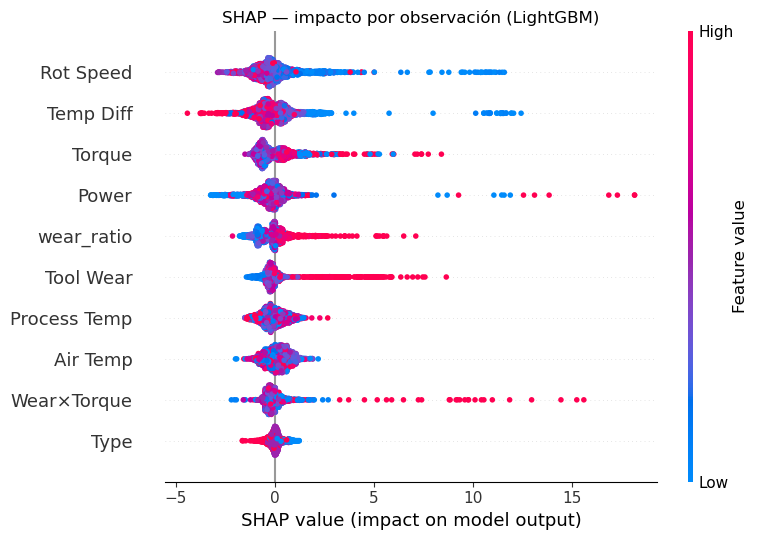

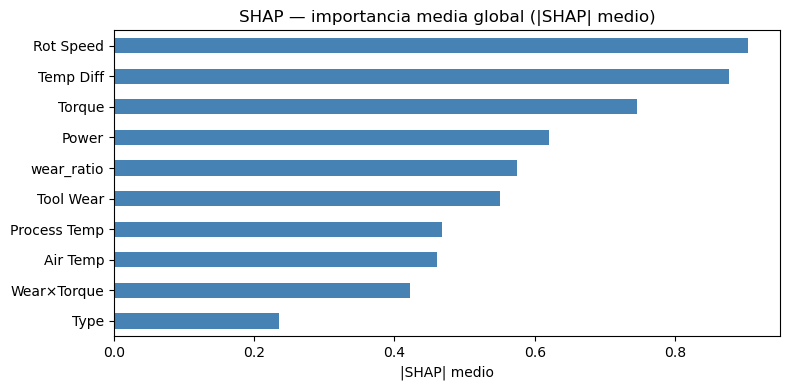

Top features por SHAP (mayor a menor impacto):
  Rot Speed          0.90438
  Temp Diff          0.87732
  Torque             0.74587
  Power              0.62095
  wear_ratio         0.57471
  Tool Wear          0.55053
  Process Temp       0.46725
  Air Temp           0.46042
  Wear×Torque        0.42275
  Type               0.23507


In [9]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('shap no instalado — pip install shap')

if HAS_SHAP:

    feat_names = ['Type', 'Air Temp', 'Process Temp', 'Rot Speed', 'Torque',
                  'Tool Wear', 'Power', 'Temp Diff', 'Wear×Torque', 'wear_ratio']

    # TreeExplainer: eficiente para modelos de árboles (LightGBM, XGBoost, RF)
    lgbm_model = models['lgbm']
    explainer = shap.TreeExplainer(lgbm_model)
    shap_values = explainer.shap_values(X_test)

    # LightGBM binario devuelve lista [shap_clase0, shap_clase1] o array directo
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    X_test_df = pd.DataFrame(X_test, columns=feat_names)

    # ── Beeswarm: impacto de cada feature en cada observación ─────────────────────
    shap.summary_plot(sv, X_test_df, show=False, plot_type='dot')
    plt.title('SHAP — impacto por observación (LightGBM)', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Importancia media global (|SHAP|) ─────────────────────────────────────────
    mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values()
    mean_shap.plot(kind='barh', color='steelblue', figsize=(8, 4))
    plt.title('SHAP — importancia media global (|SHAP| medio)')
    plt.xlabel('|SHAP| medio')
    plt.tight_layout()
    plt.show()

    print('Top features por SHAP (mayor a menor impacto):')
    for feat, val in mean_shap.sort_values(ascending=False).items():
        print(f'  {feat:<18} {val:.5f}')

## 4. Economía del sistema — proyección robusta + roles por capa

Las tres capas operan sobre **dominios y datasets distintos** (eléctrico sin etiquetas,
mecánico con n=18–33, tabular AI4I con n=2000) y **no detectan los mismos fallos sobre
las mismas máquinas**. Por eso no existe un "recall combinado" honesto: meter las
métricas de las tres capas en una única tabla de coste invita a lecturas falsas
(p. ej. *"1+2 sale más barato que 1+2+3"*), que en realidad solo reflejan que el
recall=1.0 del CNC viene de un LOO con n=18 y que el coste está dominado por el FN.

Por tanto, en lugar de una tabla de "configuraciones de capas" comparable en €:
1. **Proyección económica solo para la Capa 3** — única con test real (n=2000) y, por
   tanto, la única cifra de €/año defendible. (El ROI con FN/FP reales del modelo ya
   está en la sección 3.1; aquí se escala a una **pyme de 5 máquinas**, con un gasto de
   mantenimiento de referencia de ~1 M€/año.)
2. **Capas 1 y 2, cualitativas** — se describen por su rol y se muestran sus métricas
   con el aviso de muestra/fiabilidad bien visible, **sin** convertirlas en €/año.


Roles y fiabilidad por capa:
                                                  Dominio                    Métrica clave            n         Evaluable en €
Capa                                                                                                                          
1 — SPARK (eléctrica)  Corriente/potencia, no supervisado       tasa anom. 5.0% (σ=0.00pp)  11 máquinas     No (sin etiquetas)
2 — KIT (prototipo)                    Vibración/mecánica                      F1 LOO 0.67           33         No (n pequeño)
2 — CNC (cold-start)                             Mecánica  F1 LOO 0.91 (recall 1.00, n=18)           18  No fiable (IC amplio)
3 — AI4I (producción)                   Tabular de fallos        recall 0.853 / prec 0.967  2000 (test)                     Sí

→ Solo la Capa 3 tiene muestra suficiente para una cifra económica defendible.

Proyección económica — pyme de 5 máquinas (solo Capa 3, métricas de test):
                   Recall  Precision  FN/año  FP/año 

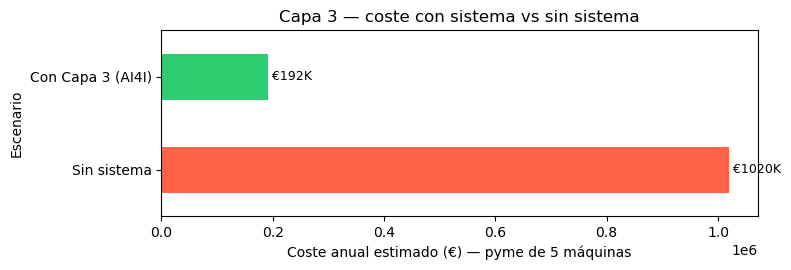

In [10]:
COST_FN, COST_FP = 3_000, 300
N_FAILURES_YEAR, N_PREDICTIONS, N_MACHINES = 68, 1000, 5   # pyme: 5 máquinas → baseline ~1M€

perf3 = cfg['performance']
m_kit, m_cnc = kit_bundle['metrics_loo'], cnc_bundle['metrics_loo']

# ── 4.1 Roles por capa (cualitativo, NO comparable en €) ──────────────────────
roles = pd.DataFrame([
    {'Capa': '1 — SPARK (eléctrica)',
     'Dominio': 'Corriente/potencia, no supervisado',
     'Métrica clave': f"tasa anom. {spark_summary['pct_anomalia'].mean():.1f}% "
                      f"(σ={spark_summary['pct_anomalia'].std():.2f}pp)",
     'n': '11 máquinas', 'Evaluable en €': 'No (sin etiquetas)'},
    {'Capa': '2 — KIT (prototipo)',
     'Dominio': 'Vibración/mecánica',
     'Métrica clave': f"F1 LOO {m_kit['recall']:.2f}",
     'n': '33', 'Evaluable en €': 'No (n pequeño)'},
    {'Capa': '2 — CNC (cold-start)',
     'Dominio': 'Mecánica',
     'Métrica clave': f"F1 LOO {m_cnc['f1']:.2f} (recall {m_cnc['recall']:.2f}, n=18)",
     'n': '18', 'Evaluable en €': 'No fiable (IC amplio)'},
    {'Capa': '3 — AI4I (producción)',
     'Dominio': 'Tabular de fallos',
     'Métrica clave': f"recall {perf3['recall']:.3f} / prec {perf3['precision']:.3f}",
     'n': '2000 (test)', 'Evaluable en €': 'Sí'},
]).set_index('Capa')
print('Roles y fiabilidad por capa:')
print(roles.to_string())
print('\n→ Solo la Capa 3 tiene muestra suficiente para una cifra económica defendible.')

# ── 4.2 Proyección económica — SOLO Capa 3 (pyme de 5 máquinas, ~1M€ mantenimiento) ──
baseline = N_FAILURES_YEAR * COST_FN * N_MACHINES   # sin sistema: todos los fallos escapan
fn3 = int(N_FAILURES_YEAR * (1 - perf3['recall'])) * N_MACHINES
fp3 = int(N_PREDICTIONS * (1 - perf3['precision']) * perf3['recall']) * N_MACHINES
coste3 = fn3 * COST_FN + fp3 * COST_FP
ahorro3 = baseline - coste3

eco = pd.DataFrame([
    {'Escenario': 'Sin sistema', 'Recall': 0.0, 'Precision': 0.0,
     'FN/año': N_FAILURES_YEAR * N_MACHINES, 'FP/año': 0,
     'Coste/año (€)': baseline, 'Ahorro/año (€)': 0},
    {'Escenario': 'Con Capa 3 (AI4I)', 'Recall': round(perf3['recall'], 3),
     'Precision': round(perf3['precision'], 3), 'FN/año': fn3, 'FP/año': fp3,
     'Coste/año (€)': coste3, 'Ahorro/año (€)': ahorro3},
]).set_index('Escenario')
print('\nProyección económica — pyme de 5 máquinas (solo Capa 3, métricas de test):')
print(eco.to_string())
print(f"\n=== Ahorro Capa 3: €{ahorro3:,.0f}/año  ({ahorro3/baseline:.0%} reducción) ===")

fig, ax = plt.subplots(figsize=(8, 2.8))
eco['Coste/año (€)'].plot(kind='barh', ax=ax, color=['tomato', '#2ecc71'])
for i, v in enumerate(eco['Coste/año (€)']):
    ax.text(v, i, f' €{v/1e3:.0f}K', va='center', fontsize=9)
ax.set_xlabel('Coste anual estimado (€) — pyme de 5 máquinas')
ax.set_title('Capa 3 — coste con sistema vs sin sistema')
plt.tight_layout(); plt.show()


## 5. Conclusiones

- **Capa 3** es la única evaluada con todas las garantías: F1=0.913, Recall=0.853 a
  umbral 0.9863 (solo 1 falsa alarma en 2.000 muestras de test). Es también la única
  con una proyección económica defendible (sección 4.2).
- **Capa 2** supera sus baselines triviales, pero con n=18/33 sus métricas son
  orientativas — el diseño correcto es el reentrenamiento incremental en planta.
- **Capa 1** no es evaluable en recall sin etiquetas; su consistencia entre máquinas
  y la separación de scores son los indicadores disponibles.
- **No existe evaluación end-to-end real del sistema**: ningún dataset contiene las
  señales de las tres capas a la vez, y las capas detectan fallos de dominios distintos
  sobre máquinas distintas. Por eso **no se combinan sus métricas en una cifra única**:
  hacerlo daba lecturas falsas (p. ej. "1+2 más barato que 1+2+3", artefacto del
  recall=1.0 del CNC con n=18). Cada capa se reporta por su rol y la economía se limita
  a la Capa 3.
